In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [17]:
df=pd.read_csv('train.csv')

In [18]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
320,321,0,3,"Dennis, Mr. Samuel",male,22.0,0,0,A/5 21172,7.2500,NaN,S
294,295,0,3,"Mineff, Mr. Ivan",male,24.0,0,0,349233,7.8958,NaN,S
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5000,B39,C
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C


In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# filling missing values

In [23]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df.drop(columns='Cabin',inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_8556\1408729586.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_8556\1408729586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


# EDA

<Axes: xlabel='Survived'>

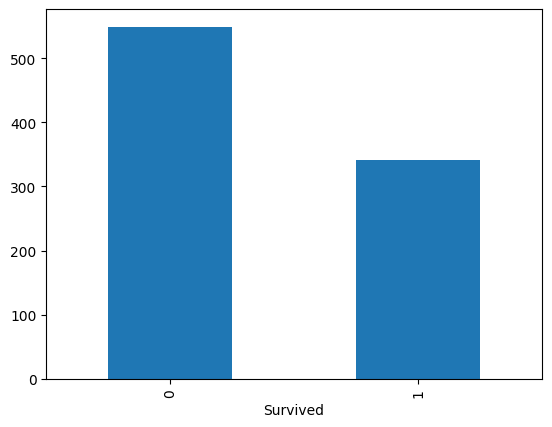

In [28]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Survived', ylabel='count'>

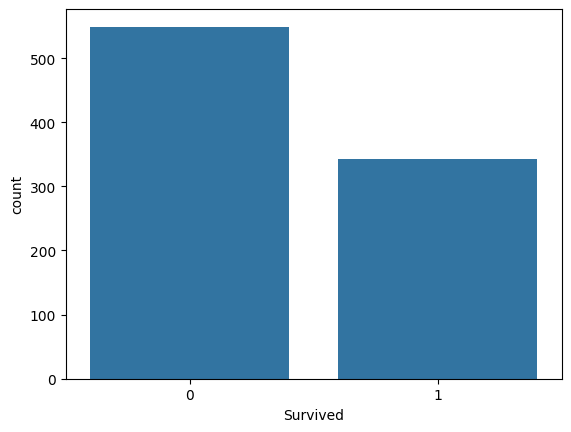

In [29]:
sns.countplot(x='Survived',data=df)

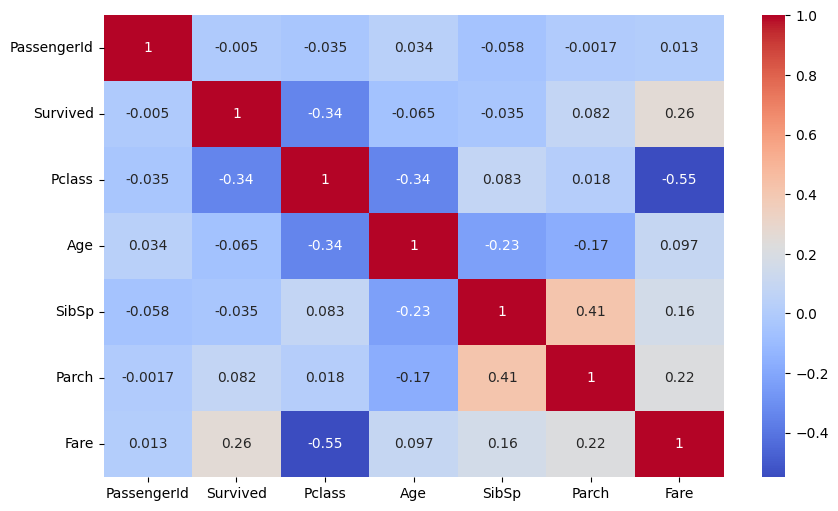

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

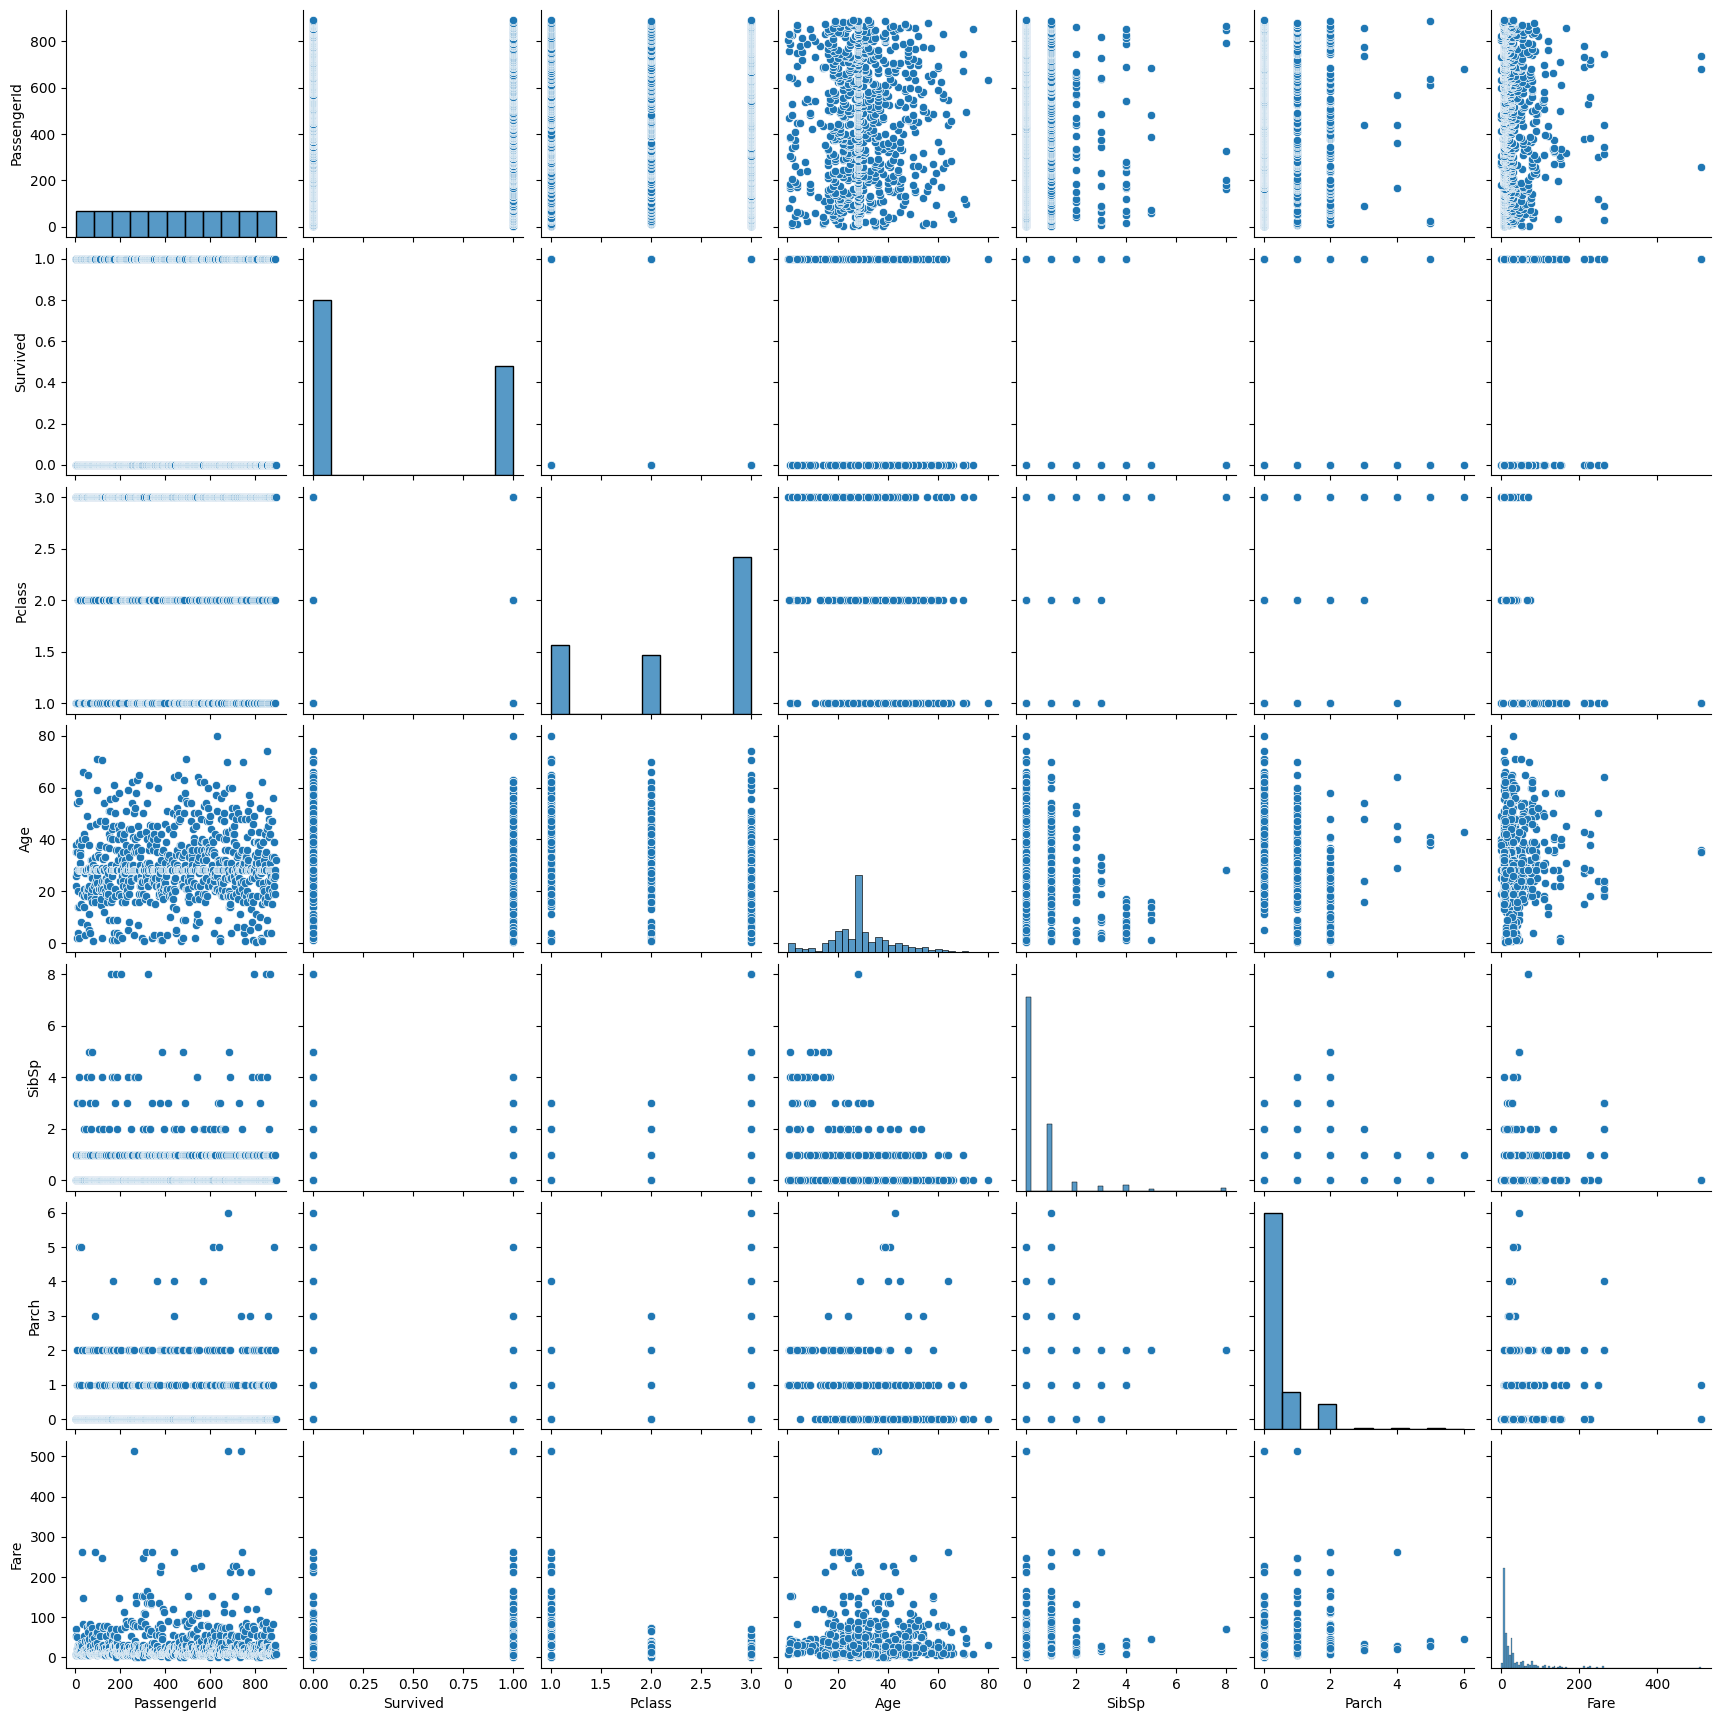

In [31]:
sns.pairplot(df)

<Axes: xlabel='Survived', ylabel='Fare'>

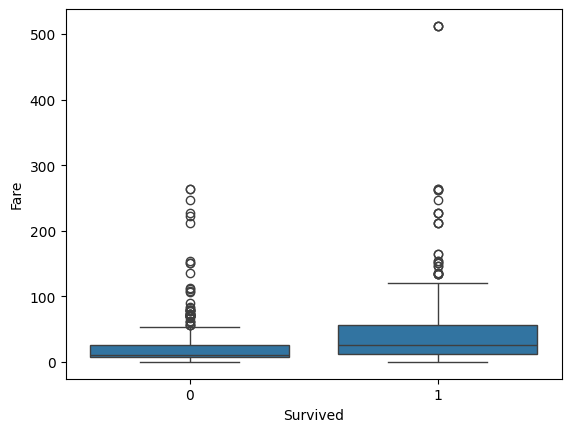

In [32]:
sns.boxplot(x='Survived', y='Fare', data=df)

<Axes: xlabel='Pclass', ylabel='count'>

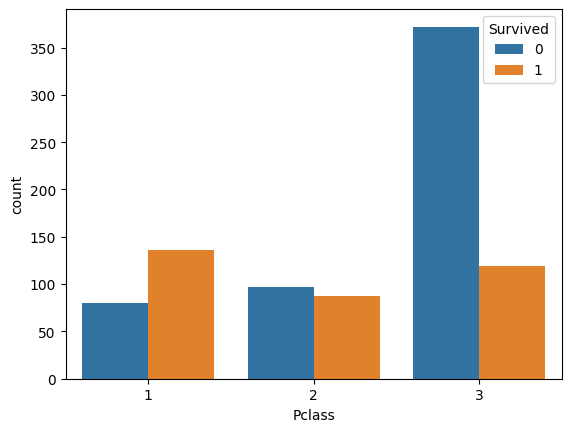

In [33]:
sns.countplot(x='Pclass', hue='Survived', data=df)

In [34]:
pd.crosstab(df['Sex'],df['Survived'],normalize='index')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


# feature engg

In [35]:
df['family_size']=df['SibSp']+df['Parch']+1

In [36]:
df['isAlone']=(df['family_size']==1).astype(int)

In [37]:
df['Title']=df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [38]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,isAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1,1,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4,0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,1,Mr


In [41]:
df['Title']=df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
df['Title']=df['Title'].replace('Mlle','Miss')
df['Title']=df['Title'].replace('Ms','Miss')
df['Title']=df['Title'].replace('Mme','Mrs')



In [43]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,35,60,100],labels=['Child','Teenager','Adult','Middle Age','Senior'])

In [44]:
df['FareGroup'] = pd.qcut(
    df['Fare'], 
    4, 
    labels=['Low','Medium','High','VeryHigh'],
    duplicates='drop'
)

In [46]:
df['TicketGroup'] = df.groupby('Ticket')['Ticket'].transform('count')

In [47]:
df = pd.get_dummies(df, columns=['Sex','Embarked','Title','AgeGroup','FareGroup'], drop_first=True)

In [48]:
df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,family_size,...,Title_2,Title_3,Title_4,AgeGroup_Teenager,AgeGroup_Adult,AgeGroup_Middle Age,AgeGroup_Senior,FareGroup_Medium,FareGroup_High,FareGroup_VeryHigh
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,...,False,False,False,False,True,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,...,True,False,False,False,False,True,False,False,False,True
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,...,False,False,False,False,True,False,False,True,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,...,True,False,False,False,True,False,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,1,...,False,False,True,False,True,False,False,True,False,False
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,1,...,False,False,False,False,True,False,False,False,True,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,4,...,False,False,False,False,True,False,False,False,True,False
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,1,...,False,False,False,False,True,False,False,False,True,False


In [50]:
df.drop(columns=['Name','Ticket'], inplace=True)

In [51]:
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,family_size,isAlone,TicketGroup,...,Title_2,Title_3,Title_4,AgeGroup_Teenager,AgeGroup_Adult,AgeGroup_Middle Age,AgeGroup_Senior,FareGroup_Medium,FareGroup_High,FareGroup_VeryHigh
0,1,0,3,22.0,1,0,7.2500,2,0,1,...,False,False,False,False,True,False,False,False,False,False
1,2,1,1,38.0,1,0,71.2833,2,0,1,...,True,False,False,False,False,True,False,False,False,True
2,3,1,3,26.0,0,0,7.9250,1,1,1,...,False,False,False,False,True,False,False,True,False,False
3,4,1,1,35.0,1,0,53.1000,2,0,2,...,True,False,False,False,True,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,1,1,1,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,1,1,...,False,False,True,False,True,False,False,True,False,False
887,888,1,1,19.0,0,0,30.0000,1,1,1,...,False,False,False,False,True,False,False,False,True,False
888,889,0,3,28.0,1,2,23.4500,4,0,2,...,False,False,False,False,True,False,False,False,True,False
889,890,1,1,26.0,0,0,30.0000,1,1,1,...,False,False,False,False,True,False,False,False,True,False


In [52]:
df.corr()['Survived'].sort_values(ascending=False)

Survived               1.000000
Title_2                0.341994
Title_1                0.335636
Fare                   0.257307
FareGroup_VeryHigh     0.233638
Title_3                0.085221
FareGroup_High         0.084239
Parch                  0.081629
TicketGroup            0.038247
AgeGroup_Teenager      0.026859
AgeGroup_Middle Age    0.017590
family_size            0.016639
Embarked_Q             0.003650
PassengerId           -0.005007
Title_4               -0.012054
SibSp                 -0.035322
AgeGroup_Senior       -0.051224
Age                   -0.064910
AgeGroup_Adult        -0.077053
FareGroup_Medium      -0.095648
Embarked_S            -0.149683
isAlone               -0.203367
Pclass                -0.338481
Sex_male              -0.543351
Name: Survived, dtype: float64

In [53]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns='Survived'),df['Survived'],test_size=0.2,random_state=42)

In [56]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')

])

In [57]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [59]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [60]:
model.fit(X_train,y_train,epochs=20,validation_data=(X_test,y_test))

Epoch 1/20
23/23 [==============================] - 9s 121ms/step - loss: 25.6615 - accuracy: 0.6236 - val_loss: 14.7471 - val_accuracy: 0.5866
Epoch 2/20
23/23 [==============================] - 0s 17ms/step - loss: 9.1709 - accuracy: 0.6208 - val_loss: 4.8449 - val_accuracy: 0.5866
Epoch 3/20
23/23 [==============================] - 0s 12ms/step - loss: 2.8082 - accuracy: 0.6222 - val_loss: 1.1361 - val_accuracy: 0.5866
Epoch 4/20
23/23 [==============================] - 0s 9ms/step - loss: 0.7831 - accuracy: 0.5337 - val_loss: 0.7176 - val_accuracy: 0.4693
Epoch 5/20
23/23 [==============================] - 0s 9ms/step - loss: 0.6872 - accuracy: 0.4593 - val_loss: 0.7112 - val_accuracy: 0.4693
Epoch 6/20
23/23 [==============================] - 0s 8ms/step - loss: 0.6794 - accuracy: 0.4761 - val_loss: 0.7057 - val_accuracy: 0.4749
Epoch 7/20
23/23 [==============================] - 0s 6ms/step - loss: 0.6765 - accuracy: 0.4817 - val_loss: 0.7032 - val_accuracy: 0.4804
Epoch 8/20
23/

In [61]:
model.save('titanic_model.h5')